In [56]:
import torch
import os
import numpy as np
import random
import matplotlib.pyplot as plt 
import pickle
from models_cartpole import RNNModel
from torch.nn.modules.utils import consume_prefix_in_state_dict_if_present # this is a thing!
from train_rnn_baseline import preprocess
# from test12ebonye_cartpole_noscale_RoPE_zerodyn import rk4_step, dynamics

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(42)

# os.environ["CUDA_VISIBLE_DEVICES"] = "3"
device = torch.device('cpu')
dataset_folder = '/data/shared/Control_ICL/Dataset_Cartpole_AIGymWithNoise_ICL_new_ranges_zero_dyn'
indist_pickle_folder = os.path.join(dataset_folder, 'picklefolder_test_indistr')
outdist_pickle_folder = os.path.join(dataset_folder, 'picklefolder_test_outofdistr')

TODO:
1. **Test data**. 
- Should we load a single sample, then inference on it? (1-10 to start off)
- How should processing work? (make sure indices the same across context lengths, dont throw out non stabilizing traces)
2. **Inferencing**. 
- Currently predicting state online. But RK4 requires previous state estimates for update. Should we store all the control input/mode predictions, then iteratively use RK4 to obtain the predicted state sequence? 
- Is the current sliding window method alright?
3. **Make Model More Complex**
- Transformer has 12 layers, see if this is feasible?

In [9]:
state_max_scale = [7.0, 8.0, 1.0, 1.0, 5.0]
control_max_scale = 15.0

def load_data(indist : bool, context_length : int):
    """Loads a batch in the test dataset"""
    assert context_length in [10, 1, 25, 50, 5]

    pickle_path = indist_pickle_folder if indist else outdist_pickle_folder
    pickle_file = os.path.join(pickle_path, f'batch_test_0_{context_length}.pkl')

    with open(pickle_file, 'rb') as file:
        xs, ys, cartmass, polemass, polelength = pickle.load(file)
        return xs, ys, cartmass, polemass, polelength

def sample(indist : bool, n : int):
    """Samples a trajectory from each context batch with the same physical parameters, n times.
    
    Inputs:
    - indist : indicates data is in distribution
    - n : number of samples to make per context_length

    Outputs:
    - context_batches : list of batches by context_length with the same physical parameters
    """
    context_batches = []
    idx = torch.randint(low=0, high=2999, size=(n,), device=device)
    for context_length in [1, 5, 10, 25, 50]:
        xs, ys, cartmass, polemass, polelength = load_data(indist, context_length)
        sample = (xs[idx, ...].to(device), 
                  ys[idx, ...].to(device), 
                  torch.tensor(cartmass[idx, ...], device=device), 
                  torch.tensor(polemass[idx, ...], device=device), 
                  torch.tensor(polelength[idx, ...], device=device))
        context_batches.append(sample)
    return context_batches

def process_data(xs : torch.tensor, ys : torch.tensor):
    """Processes data for inference.
    
    Inputs:
    - xs : raw state data (x, x., t, t.) [batch_size, 560, 4]
    - ys : raw control/mode data (u, m) [batch_size, 559, 2]

    Outputs:
    - xs_sc : sequence of normalized (x, x., cos(t), sin(t), t.) [batch_size, 540, 5]
    - ys_sc : sequence of normalized (u, m) [batch_size, 540, 2]
    """

    # Computing sin/cos Tensors
    xs_cos_tensor = torch.cos(xs[:, :, 2])
    xs_sin_tensor = torch.sin(xs[:, :, 2])
    xs_tensor_updated = torch.cat((xs[:, :, :2], xs_cos_tensor.unsqueeze(-1), xs_sin_tensor.unsqueeze(-1), xs[:, :, 3:]), dim=-1)
    
    # Normalizing Data
    xs_sc = xs_tensor_updated / torch.tensor(state_max_scale, device=xs.device)
    if ys == None:
        return xs_sc
    
    ys_sc = ys / torch.tensor([control_max_scale, 1.0], device=ys.device)
    ys_sc_for_model = ys_sc.clone()
    ys_sc_for_model[..., 1] = ys_sc_for_model[..., 1] + 1 # -1, 0, 1 -> 0, 1, 2 (model has seen only this during training)

    return xs_sc, ys_sc_for_model

In [10]:
# Adapted from test12ebonye_cartpole_noscale_RoPEzerodyn.py to support batching.

def cartpole_dynamics(state, u, cartmass, polemass, polelength, g=9.81):
    """
    Computes the dynamics of the cartpole system.
    Inputs:
        state: (batch, 4) tensor representing [x, x_dot, theta, theta_dot]
        u: (batch,) tensor representing the control input (force applied to the cart)
        cartmass: (batch,), mass of the cart
        polemass: (batch,), mass of the pole
        polelength: (batch,), length of the pole
        g: float, acceleration due to gravity (default 9.81 m/s^2)
    Returns:
        dydt: (batch, 4) tensor representing the derivatives [x_dot, xacc, theta_dot, thetaacc]
    """
    x, x_dot, theta, theta_dot = state[..., 0], state[..., 1], state[..., 2], state[..., 3] # unpack for batching
    force = u

    costheta = torch.cos(theta)
    sintheta = torch.sin(theta)
    
    temp = (force + sintheta * polelength * polemass * theta_dot**2) / (cartmass + polemass)
    thetaacc = (g * sintheta - costheta * temp) / (polelength * (4.0 / 3.0 - polemass * costheta**2 / (cartmass + polemass)))
    xacc = temp - (polemass * polelength * thetaacc * costheta) / (cartmass + polemass)

    return torch.stack([x_dot, xacc, theta_dot, thetaacc], dim=-1).to(state.dtype)

def rk4_step(state, u, dt, dynamics, cartmass, polemass, polelength):
    """
    Perform a single RK4 step.
    Inputs:
        state: (batch, 4)
        u: (batch,)
        dt: float
        dynamics: function that takes (state, u) and returns derivative
    Outputs:
        state_next: (batch, 4)
    """
    
    k1 = dynamics(state, u, cartmass, polemass, polelength)
    k2 = dynamics(state + 0.5 * dt * k1, u, cartmass, polemass, polelength)
    k3 = dynamics(state + 0.5 * dt * k2, u, cartmass, polemass, polelength)
    k4 = dynamics(state + dt * k3, u, cartmass, polemass, polelength)
    state_next = state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return state_next

def solver(x, a, cartmass, polemass, polelength, dt=0.1, dynamics=cartpole_dynamics):
    """
    Perform a single RK4 step.
    Inputs:
        state: (batch, 4)
        u: (batch,)
        dt: float
        dynamics: function that takes (state, u) and returns derivative
    Returns:
        state_next: (batch, 4)
    """
    return rk4_step(x, a, dt, dynamics, cartmass, polemass, polelength) 

torch.Size([5, 120, 4])


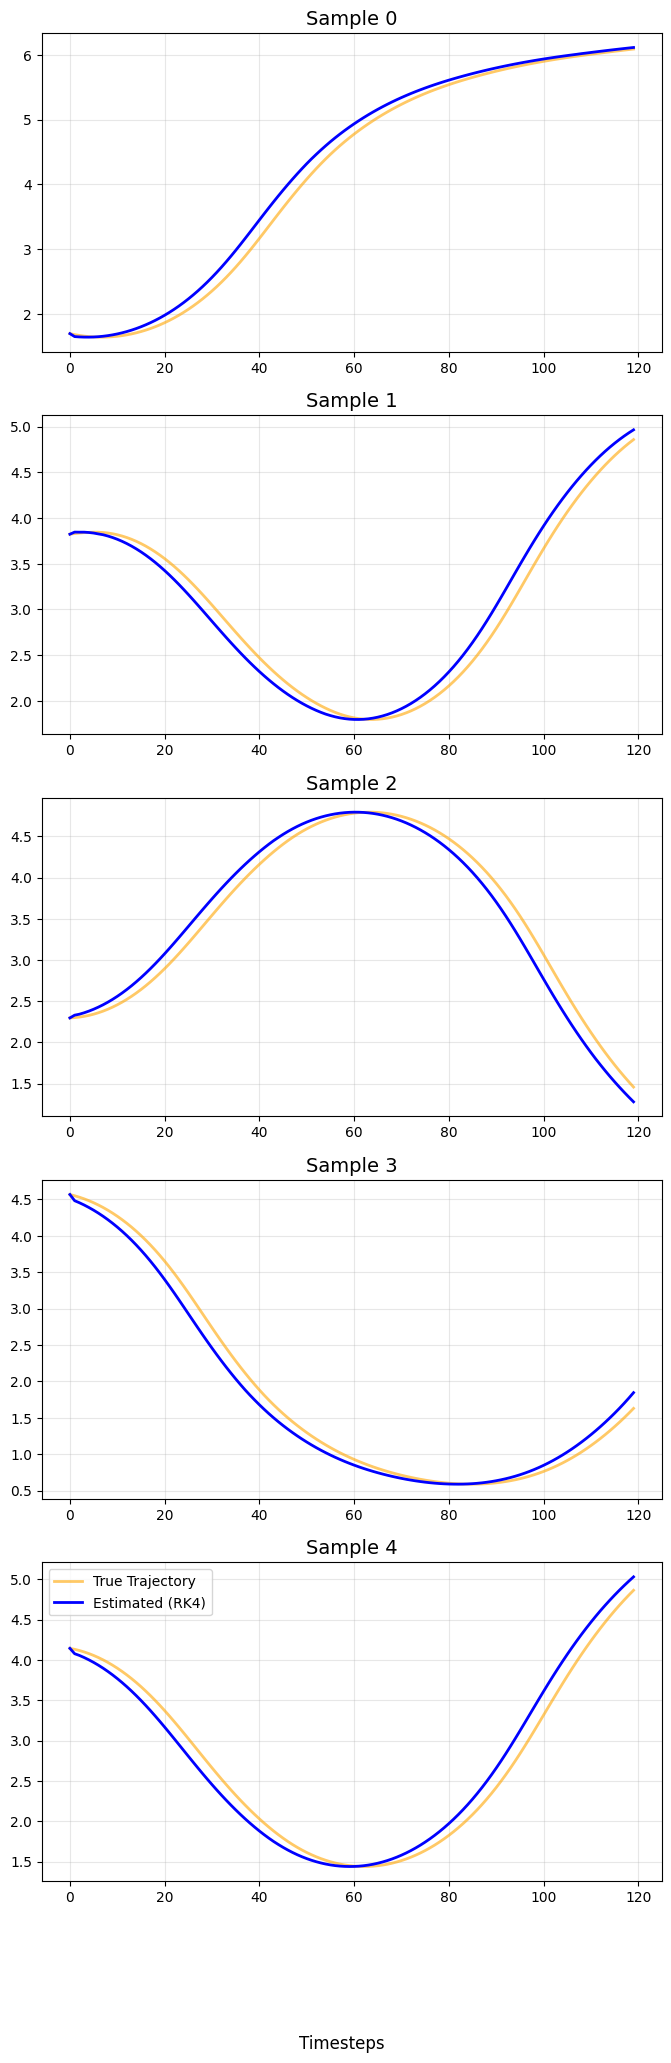

<Figure size 640x480 with 0 Axes>

In [29]:
context_batches = sample(True, 5)
xs, ys, cartmasses, polemasses, polelengths = context_batches[0] # batch of context length 1

true_trajectories = torch.cat((xs[:, :120, :], ys[:, :120, :]), dim=-1)
estimated_trajectories = [xs[:, 0, :].unsqueeze(1)] + [solver(xs[:, i, :], ys[:, i+1, 0], cartmasses, polemasses, polelengths).unsqueeze(1) for i in range(0, 119)]
estimated_trajectories = torch.cat(estimated_trajectories, dim=1)
print(estimated_trajectories.shape)

fig, axes = plt.subplots(len(context_batches[0]), 1, figsize=(8,24))
for i in range(len(context_batches[0])): # over trajectories in batch
    ax = axes.flatten()[i]
    ax.plot(true_trajectories[i, :, 2], color='orange', linewidth=2, alpha=0.6, label='True Trajectory')
    ax.plot(estimated_trajectories[i, :, 2], color='blue', linewidth=2, label='Estimated (RK4)')  
    ax.set_title(f"Sample {i}", fontsize=14)
    ax.grid(True, alpha=0.3)

fig.text(0.5, 0.04, 'Timesteps', ha='center', fontsize=12)
plt.legend()
plt.show()
plt.tight_layout()

In [45]:
def build_rnn(args):
    return RNNModel(n_dims=args['n_dims'], 
                    hidden_size=args['hidden_size'],
                    num_layers=args['num_layers'], 
                    cell_type=args['cell_type'],
                    n_embd=args['n_embd'])

def inference_step(model : torch.nn.Module, 
                   trajectory : torch.tensor,
                   s_prev : torch.tensor,
                   context_length : int,
                   cartmass : torch.tensor,
                   polemass : torch.tensor,
                   polelength : torch.tensor, 
                   solver=solver) -> torch.tensor:
    """
    Inputs:
        - model : RNN baseline for cartpole system.
        - trajectory : running trajectory [batch_size, variable, 7]
        - s_prev : prediction of previous state [batch_size, 4]
        - context_length : truncate trajectory to last context_length timesteps
        - cartmass : physical parameter used for solver [batch_size,]
        - polemass : physical parameter used for solver [batch_size,]
        - polelength : physical parameter used for solver [batch_size,]
        - solver : s_t+1 = f(s_t, u_t+1, mc, mp, l)
    
    Outputs:
        - updated_trajectory : trajectory appended by model prediction
        - s_pred : state predicted via solver and control input
    """

    context = trajectory[:, -context_length:, :].to(device)
    s, m, a = context[..., :5], context[..., 6, None], context[..., 5, None]

    model.eval()
    with torch.no_grad():
        _, m_logits, a_pred = model(s, m, a, inf=True)
    
    a_pred_unscaled = (a_pred * control_max_scale).view(a_pred.shape[0]) # denormalizing control input for rk4
    s_pred_raw = solver(s_prev, a_pred_unscaled, cartmass, polemass, polelength) # raw, not normalized (x, x., t, t.)
    s_pred_sc = process_data(s_pred_raw.unsqueeze(1), None) # normalized (x, x., cos(t), sin(t), t.)

    m_pred = torch.argmax(m_logits, dim=-1, keepdim=True)
    prediction = torch.cat((s_pred_sc, a_pred, m_pred), dim=-1)
    
    updated_trajectory = torch.concat((trajectory.clone().to(device), prediction), dim=1)
    return updated_trajectory, s_pred_raw

In [50]:
def inference(model : torch.nn.Module, 
              context : torch.tensor,
              s_prevs : torch.tensor,
              cartmass : torch.tensor,
              polemass : torch.tensor,
              polelength : torch.tensor,
              rollout_length=120, 
              solver=solver):
    """
    Inputs:
        - model : RNN baseline for cartpole system.
        - context : running trajectory [batch_size, context_length, 7]
        - s_prevs : list of predictions of previous states [batch_size, context_length, 4]
        - cartmass : physical parameter used for solver [batch_size,]
        - polemass : physical parameter used for solver [batch_size,]
        - polelength : physical parameter used for solver [batch_size,]
        - rollout_length : number of timesteps to roll out trajectory to
        - solver : s_t+1 = f(s_t, u_t+1, mc, mp, l)
    
    Outputs:
        - trace : full trajectory rollout by model [batch_size, rollout_length, 7]
        - s_preds : full state sequence prediction [batch_size, rollout_length, 4]
    """
    trace = context.to(device)
    context_length = context.shape[1]
    s_preds, s_pred = s_prevs, s_prevs[-1]
    for _ in range(rollout_length - context_length):
        trace, s_pred = inference_step(model, trace, s_pred, context_length, cartmass, polemass, polelength, solver)
        s_preds.append(s_pred)

    trace = trace.detach() * torch.tensor(state_max_scale + [control_max_scale, 1.0], device=device) # denormalizing trace
    trace[:, :, -1] = trace[:, :, -1] - 1 # 0, 1, 2 -> -1, 0, 1
    s_preds = torch.stack(s_preds, dim=1)

    return trace, s_preds

In [76]:
def plot_traces(context_batches : list[torch.tensor], 
                context_length : int, 
                num_traces : int,
                rollout_length : int) -> None:
    """
    Inputs:
        - context_batches : list of batches by context_length with the same physical parameters
        - context_length : length of context in batch 
        - num_traces : number of trajectories to plot
        - rollout_length : number of timesteps to roll out trajectory to
    """
    assert num_traces <= context_batches[0][0].shape[0], 'Number of traces must be at most the number of samples in batch'

    context_length_to_index = {1:0, 5:1, 10:2, 25:3, 50:4}

    batch = context_batches[context_length_to_index[context_length]]
    for s in range(num_traces):
        xs, ys, cartmasses, polemasses, polelengths = [batch[j][s].unsqueeze(0) for j in range(len(batch))] #  grab sth batch and add back batch dimension
        trajectory = torch.cat((xs[:, :rollout_length, :], ys[:, :rollout_length, :]), dim=-1)

        trajectory_for_model = torch.cat(process_data(xs[:, :rollout_length, :], ys[:, :rollout_length, :]), dim=-1)
        context = trajectory_for_model[:, :context_length, :]
        s_prevs = [trajectory[:, i, :4] for i in range(context_length)]

        trace, s_preds = inference(model=model, 
                                   context=context, 
                                   s_prevs=s_prevs, 
                                   cartmass=cartmasses, 
                                   polemass=polemasses, 
                                   polelength=polelengths)

        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes_flattened = axes.flatten()

        features = ['$x$', '$\dot{x}$', '$\\theta$', '$\dot{\\theta}$', '$u$', '$m$']
        for i, feature in enumerate(features):
            true_data = trajectory[..., i].squeeze()
            if i < 4:
                data = s_preds[..., i].squeeze()
            else:
                data = trace[..., i+1].squeeze()
                
            ax = axes_flattened[i]

            ax.scatter(np.arange(rollout_length), true_data, color='red', label='Ground Truth', alpha=0.5)
            ax.scatter(np.arange(context_length-1, len(data)), data[context_length-1:], color='blue', label='Predicted')
            ax.scatter(np.arange(context_length), data[:context_length], color='orange', linestyle='--', label='Context')
            
            ax.set_title(feature, fontsize=14)
            ax.grid(True, alpha=0.3)

        fig.text(0.5, 0.04, 'Timesteps', ha='center', fontsize=12)
        plt.suptitle(f'RNN Cartpole Trajectory Completion for Context Length {context_length}', fontsize=14, y=0.98)
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.legend()

        output_dir = './visualizations/1_layer_rnn_h256_eval'
        file_path = os.path.join(output_dir, f'{s}_context_length_{context_length}')
        plt.savefig(file_path, dpi=300) 
        plt.show()

        plt.close()

        

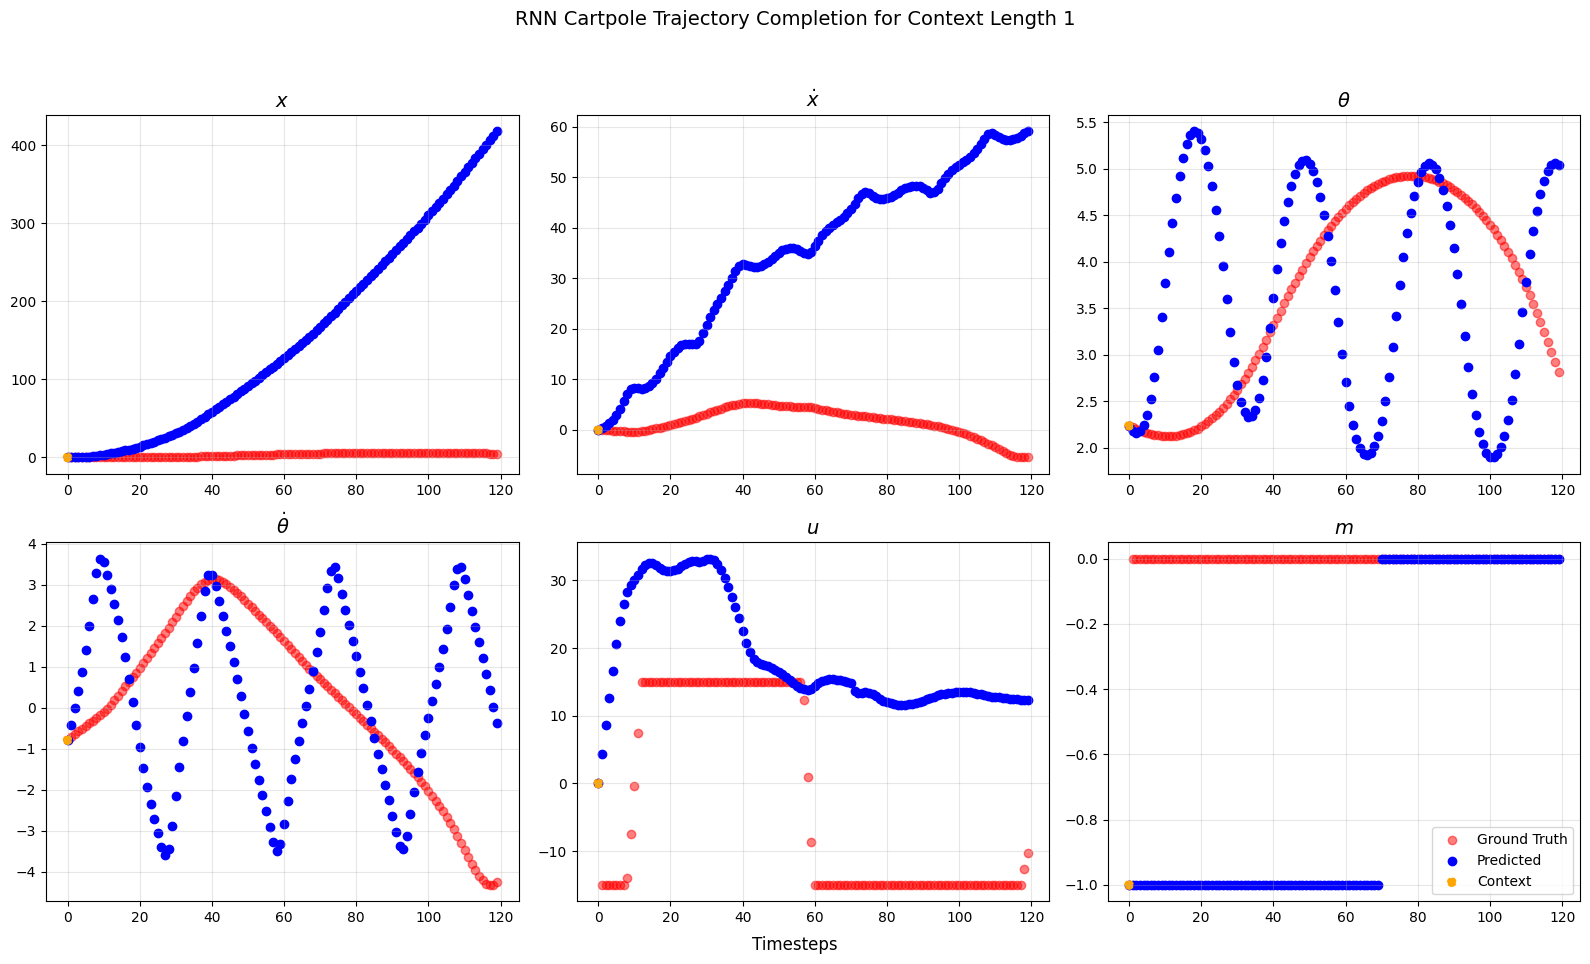

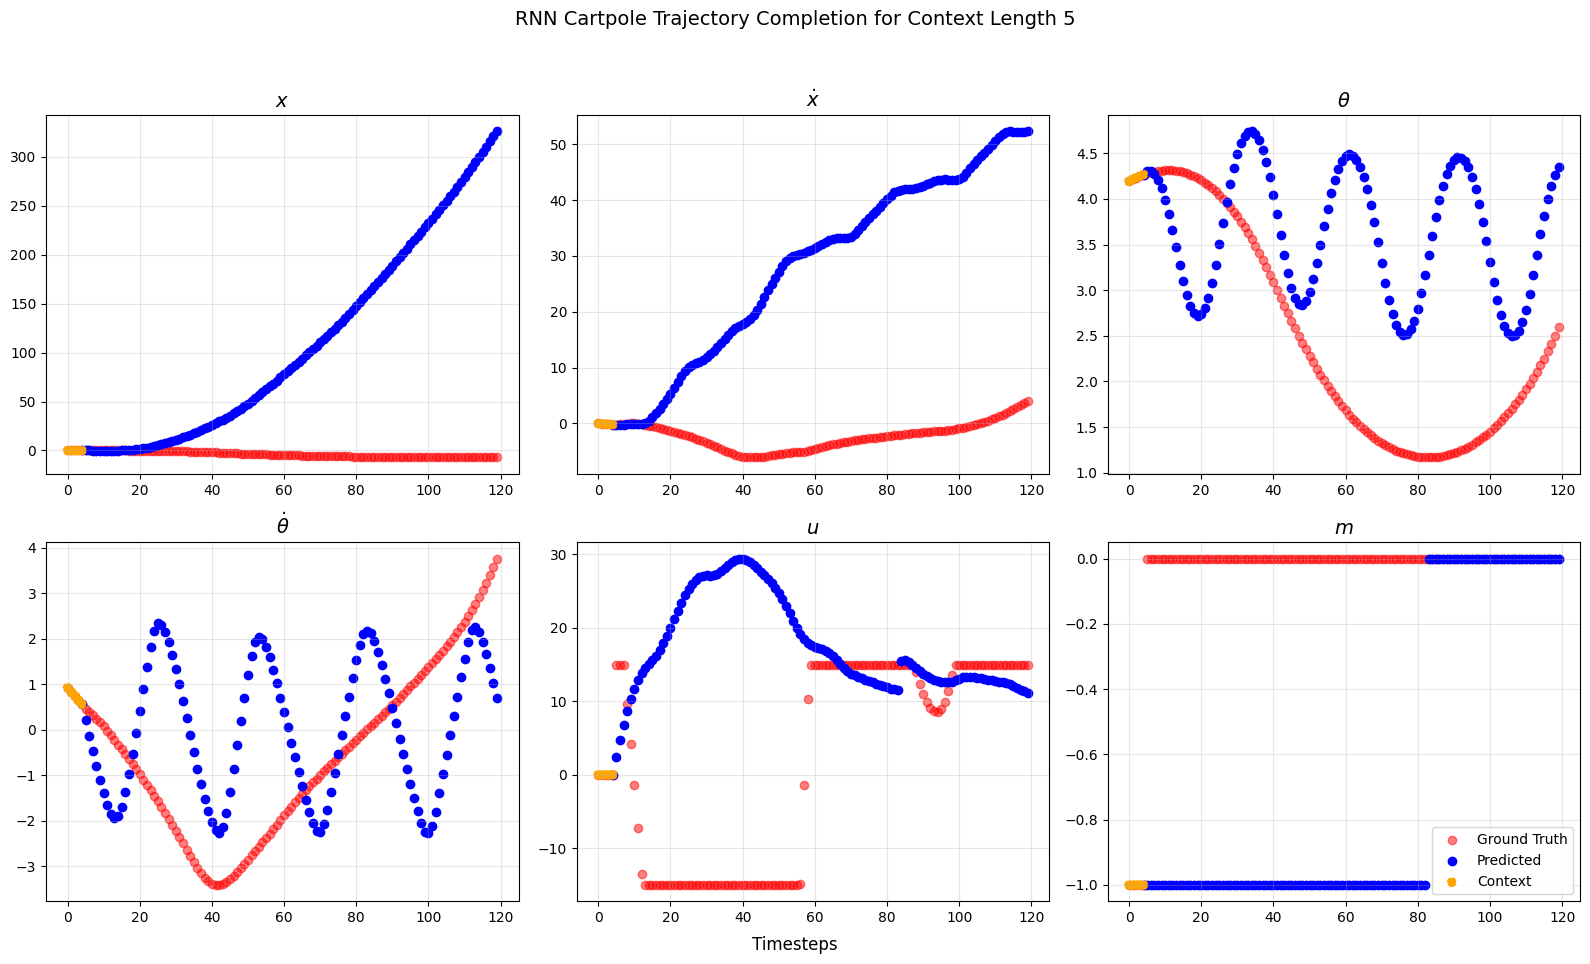

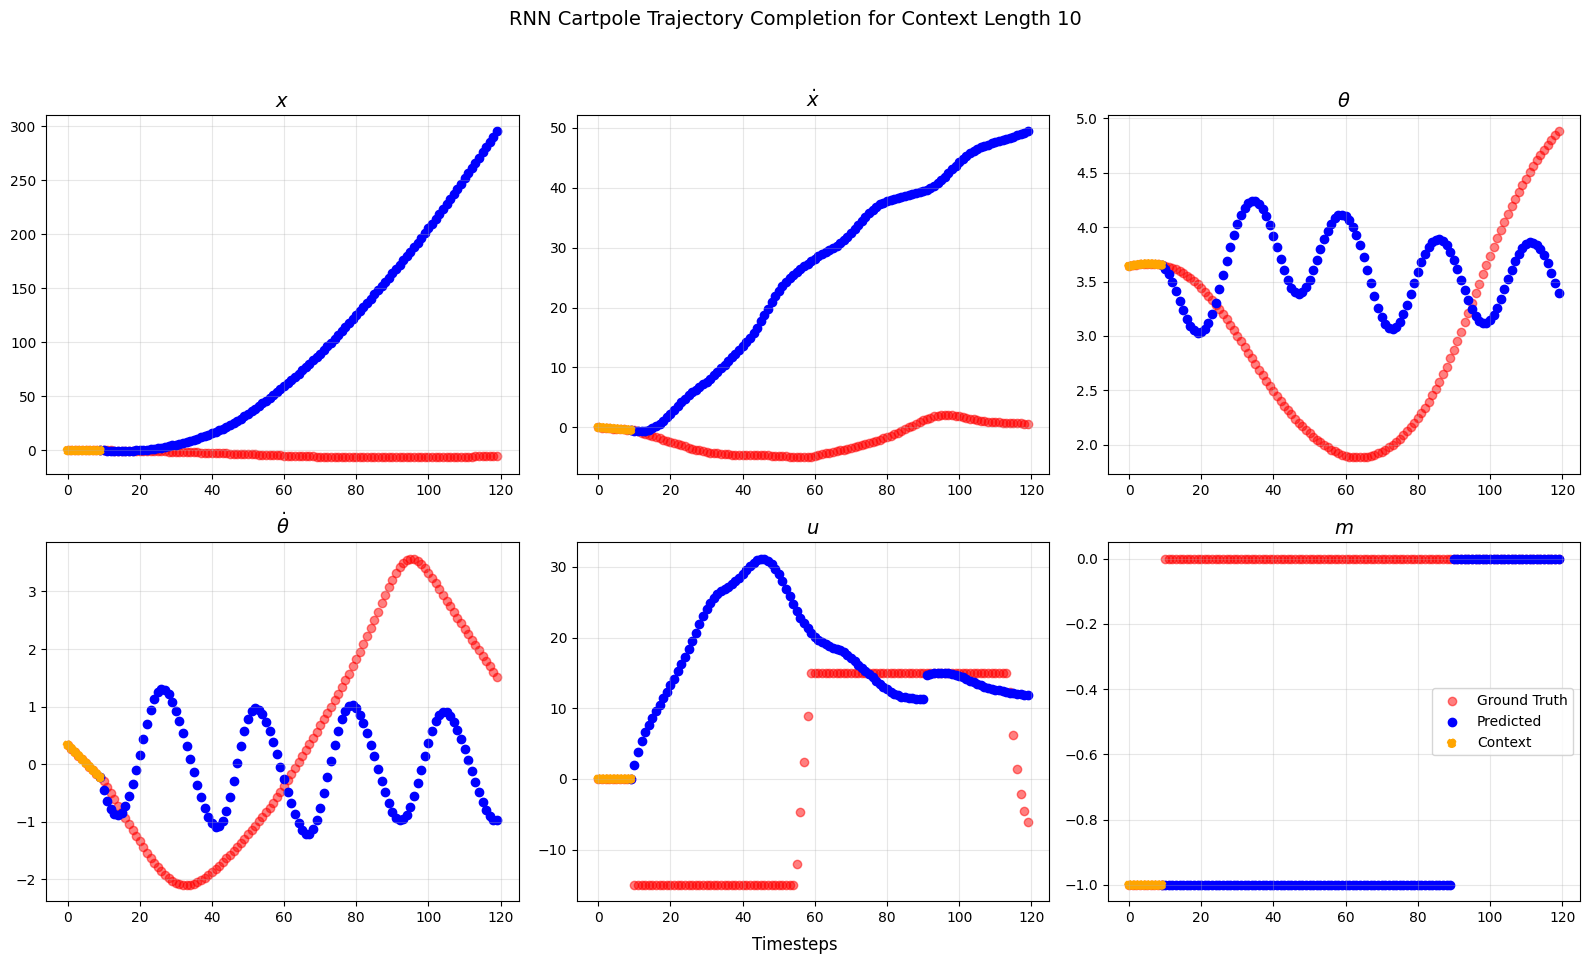

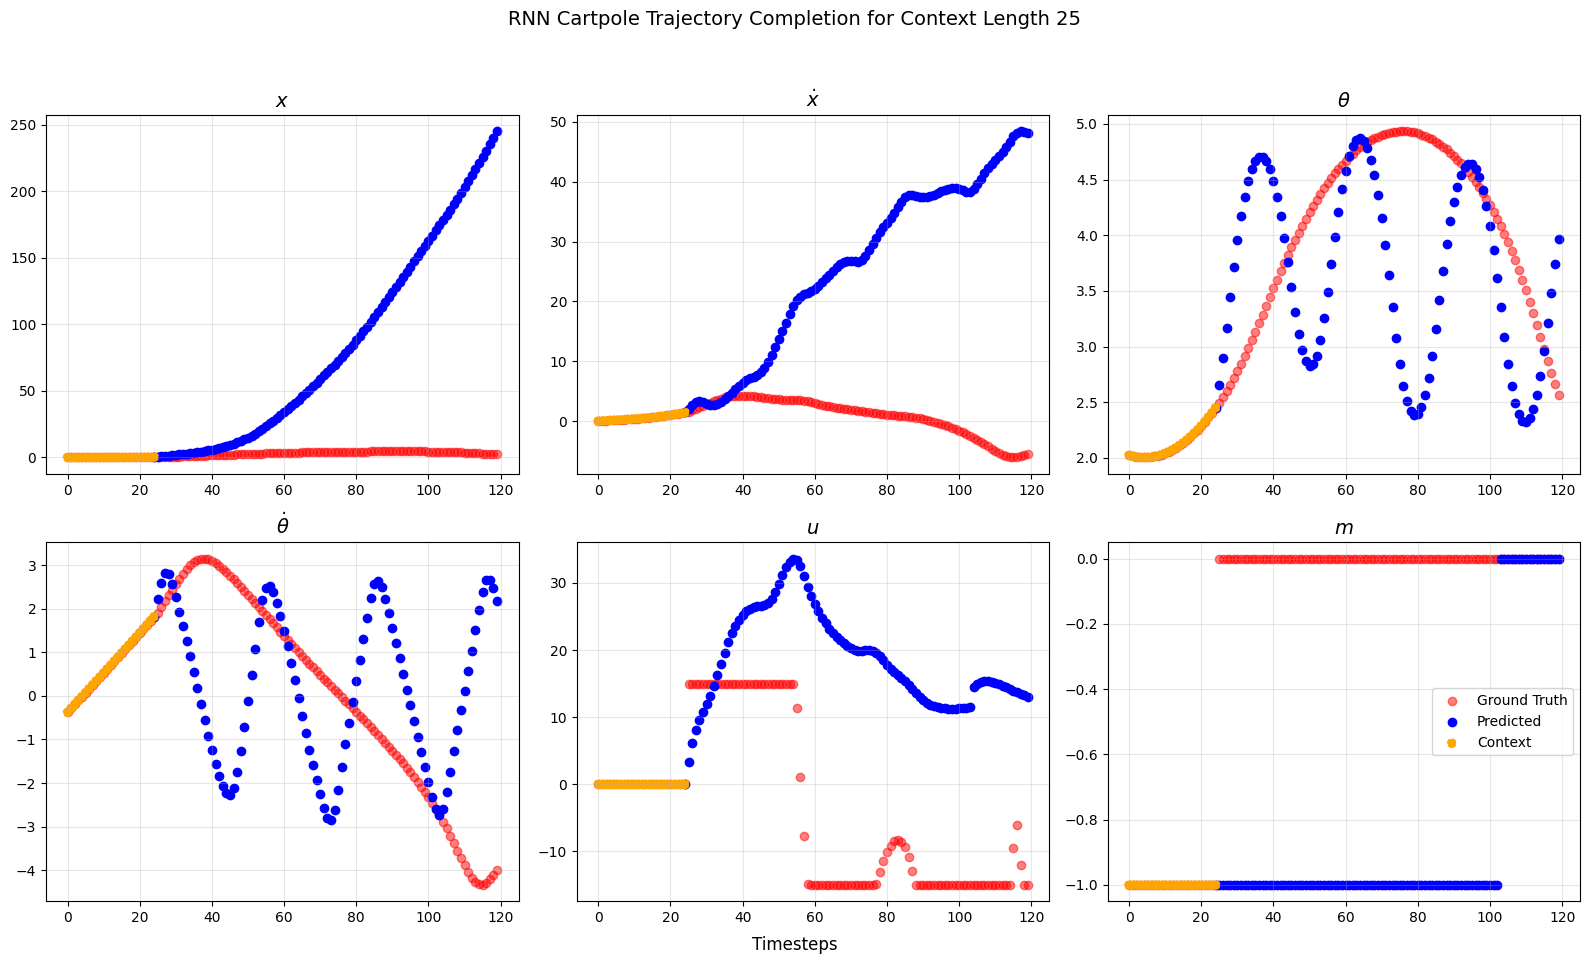

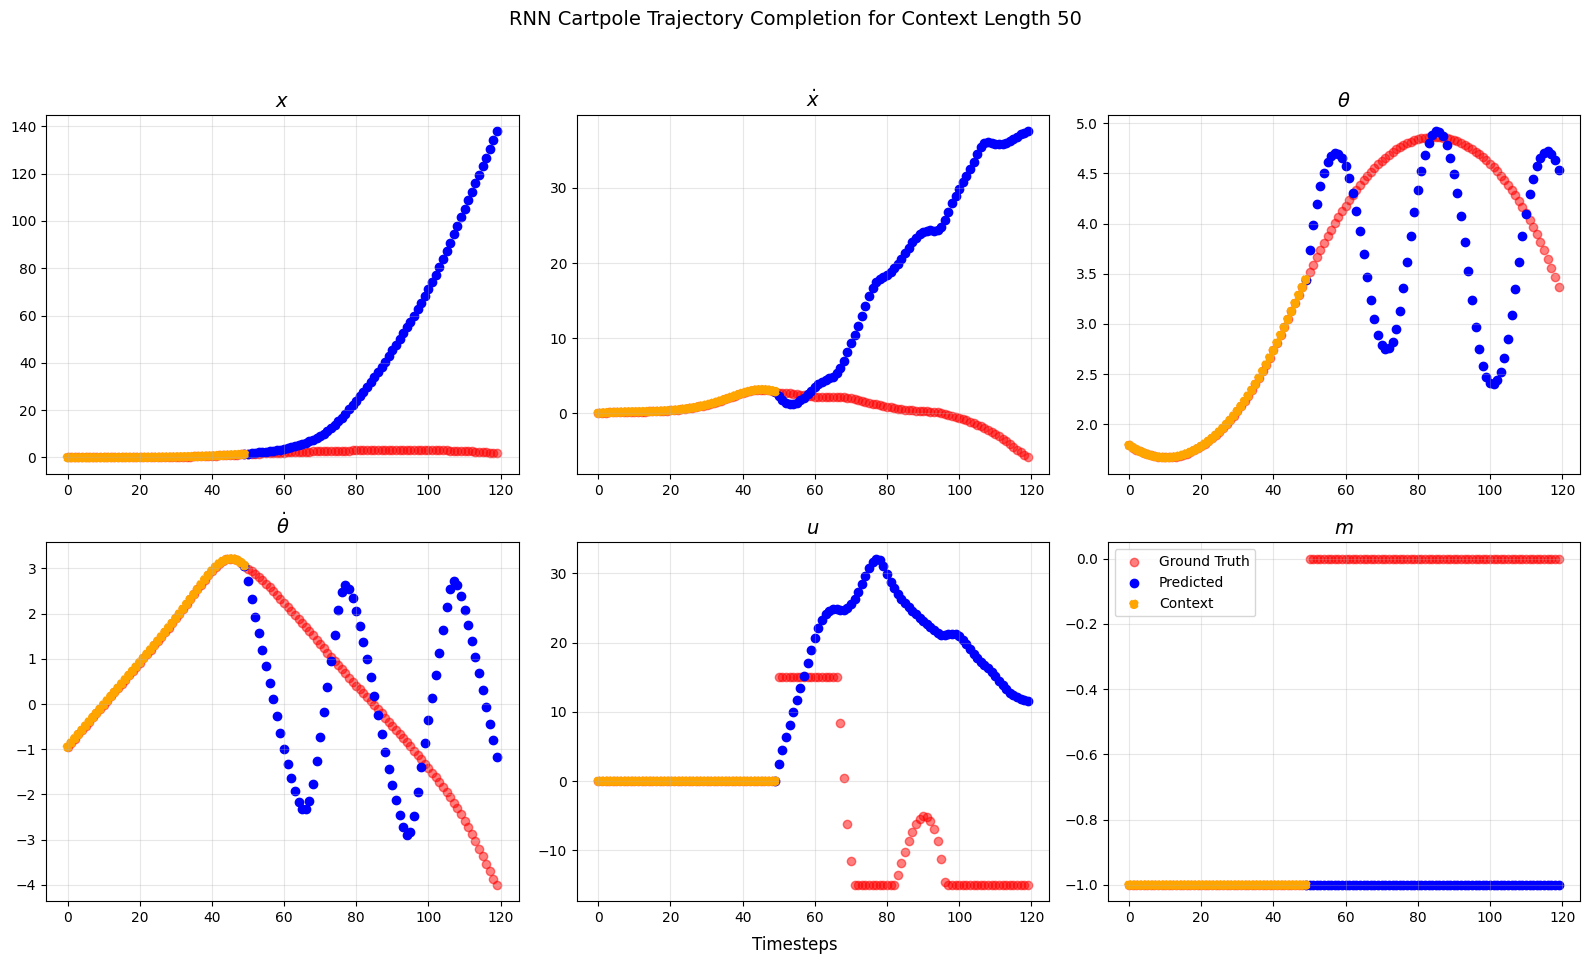

In [77]:
model_config = {'n_dims': {'state': 5, 'distance': 1, 'mode': 3,'control': 1},
                'hidden_size': 256,
                'num_layers': 1,
                'cell_type': 'rnn',
                'n_embd': 256}
checkpoint_path = './models/cartpole_rnn/single_layer_standard_rnn/checkpoint_epoch1_step225547.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)
consume_prefix_in_state_dict_if_present(checkpoint['model_state_dict'], prefix='module.')
model = build_rnn(model_config)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)

# context_batches = sample(indist=True, n=5)
for context_length in [1, 5, 10, 25, 50]:
    plot_traces(context_batches=context_batches,
                context_length=context_length,
                num_traces=1,
                rollout_length=120)